# Reproduksi Tutorial: Model Explainability - Skforecast

**Sumber:** https://skforecast.org/0.15.1/user_guides/explainability.html

Tutorial ini mereproduksi panduan explainability dari skforecast yang membahas:
- Feature Importance
- SHAP Values
- Permutation Feature Importance
- Partial Dependence Plots

---
## 0. Install Dependencies

Jalankan cell berikut jika library belum terinstall (uncomment jika di Google Colab).

In [9]:
# Uncomment baris berikut jika menjalankan di Google Colab atau belum install
# !pip install skforecast lightgbm shap matplotlib pandas

---
## 1. Libraries and Data

In [10]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

In [11]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


In [12]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


In [13]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

print(f"Train shape: {data_train.shape}")
print(f"Test shape:  {data_test.shape}")
print(f"\nTrain period: {data_train.index.min()} to {data_train.index.max()}")
print(f"Test period:  {data_test.index.min()} to {data_test.index.max()}")

Train shape: (1087, 2)
Test shape:  (10, 2)

Train period: 2011-12-31 00:00:00 to 2014-12-21 00:00:00
Test period:  2014-12-22 00:00:00 to 2014-12-31 00:00:00


---
## 2. Create and Train Forecaster

In [14]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-10 19:16:50 
Last fit date: 2026-06-10 19:16:53 
Skforecast version: 0.22.0 
Python version: 3.10.6 
Forecaster id: None

---
## 3. Model-specific Feature Importances

### Extract Feature Importances from Trained Forecaster

In [15]:
# Predictors importances
# ==============================================================================
importances = forecaster.get_feature_importances()
importances

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


---
## 4. SHAP Values

### 4.1 Training Matrices

In [16]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


Time
2012-01-07    200693.270298
2012-01-08    200061.614738
2012-01-09    216201.836844
Freq: D, Name: y, dtype: float64

### 4.2 SHAP Explainer

In [17]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

### 4.3 SHAP Summary Plot (Bar)

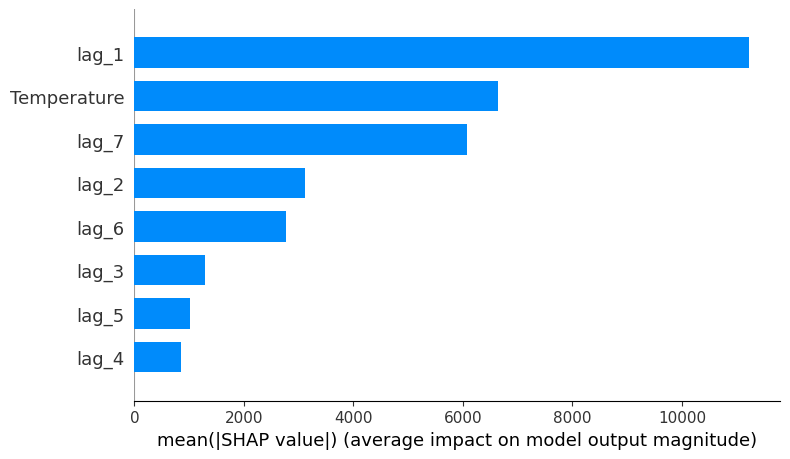

In [18]:
# SHAP Summary Plot (bar)
# ==============================================================================
shap.summary_plot(shap_values, X_train, plot_type="bar")

### 4.4 SHAP Summary Plot (Beeswarm)

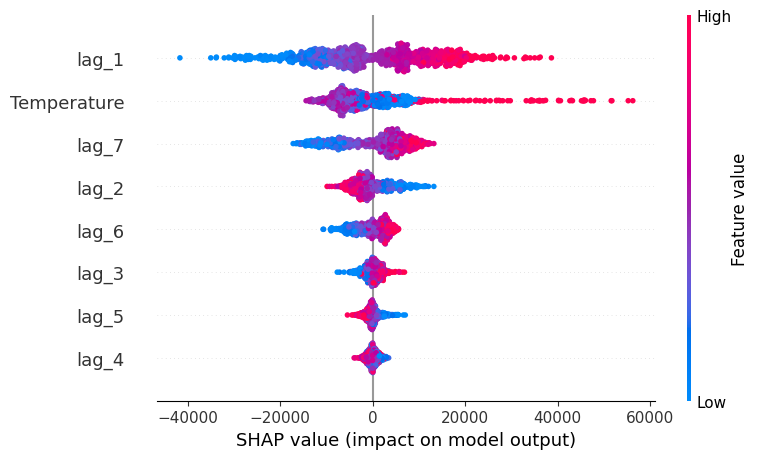

In [19]:
# SHAP Summary Plot (beeswarm)
# ==============================================================================
shap.summary_plot(shap_values, X_train)

### 4.5 Explain Individual Observations

In [20]:
# Force plot for the first observation
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

In [21]:
# Force plot for the first 200 observations in the training set
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

### 4.6 SHAP Dependence Plots

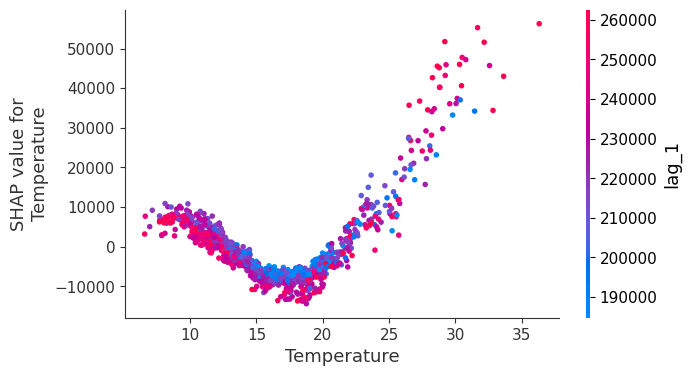

In [22]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

### 4.7 Explain Forecasted Values

In [23]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

2014-12-22    241514.532543
2014-12-23    226165.936559
2014-12-24    220506.468700
2014-12-25    209260.948991
2014-12-26    184885.145832
2014-12-27    195623.591810
2014-12-28    222766.340659
2014-12-29    223112.716406
2014-12-30    219103.891733
2014-12-31    217948.965404
Freq: D, Name: pred, dtype: float64

In [24]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


In [25]:
# Force plot for a specific prediction
# ==============================================================================
predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values_predict = explainer.shap_values(X_predict)
shap.force_plot(
    explainer.expected_value,
    shap_values_predict[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

---
## 5. Permutation Feature Importance

In [26]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================
r = permutation_importance(
        estimator    = forecaster.estimator,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances_perm = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)
importances_perm

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


---
## 6. Partial Dependence Plots

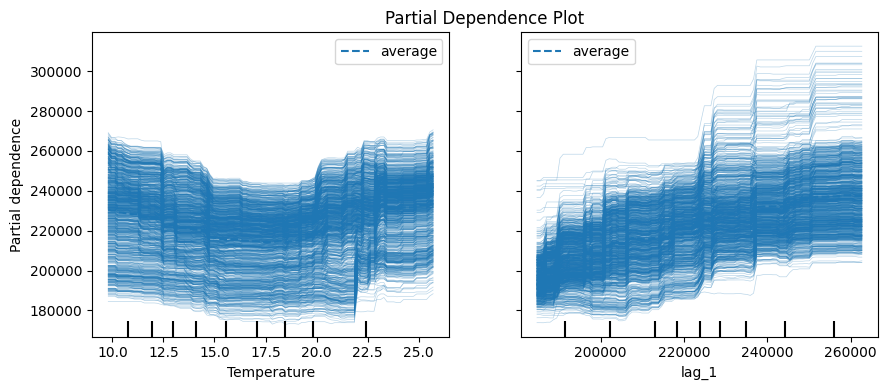

In [27]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

---
---
# JAWABAN PERTANYAAN ANALISIS

---
## Pertanyaan 1: Analisa prediksi tentang apa?

Analisa prediksi pada tutorial ini adalah tentang **peramalan (forecasting) permintaan listrik harian (Daily Electricity Demand)** di wilayah **Victoria, Australia**.

Dataset yang digunakan adalah `vic_electricity` yang berisi data permintaan listrik setengah jam-an (*half-hourly*) yang kemudian diagregasi menjadi frekuensi **harian**:
- **Demand** (permintaan listrik) dijumlahkan per hari (`sum`)
- **Temperature** (suhu rata-rata) dirata-ratakan per hari (`mean`)

Model dilatih untuk memprediksi **total permintaan listrik harian** di masa depan berdasarkan:
- Nilai permintaan listrik di hari-hari sebelumnya (lag features)
- Suhu rata-rata harian (exogenous variable)

Selain prediksi, fokus utama tutorial ini adalah **explainability** (interpretasi model), yaitu:
- Fitur apa yang paling berpengaruh terhadap prediksi?
- Bagaimana pengaruh masing-masing fitur terhadap output model?
- Mengapa model membuat prediksi tertentu pada tanggal tertentu?

---
## Pertanyaan 2: Bagaimana bentuk data trainingnya (apa saja inputnya dan apa outputnya)?

### Output (Target / y):
- **`Demand`** — Total permintaan listrik harian (dalam satuan energi)
- Ini adalah variabel yang ingin diprediksi

### Input (Features / X):
Skforecast secara otomatis mentransformasi data time series menjadi format **supervised learning** dengan membuat fitur-fitur berikut:

| Fitur | Deskripsi |
|-------|----------|
| `lag_1` | Nilai Demand **1 hari sebelumnya** |
| `lag_2` | Nilai Demand **2 hari sebelumnya** |
| `lag_3` | Nilai Demand **3 hari sebelumnya** |
| `lag_4` | Nilai Demand **4 hari sebelumnya** |
| `lag_5` | Nilai Demand **5 hari sebelumnya** |
| `lag_6` | Nilai Demand **6 hari sebelumnya** |
| `lag_7` | Nilai Demand **7 hari sebelumnya** |
| `Temperature` | Suhu rata-rata harian (**variabel eksogen**) |

### Contoh Struktur Data Training:

```
Input (X_train):                                             Output (y_train):
| lag_1  | lag_2  | lag_3  | ... | lag_7  | Temperature |    | Demand  |
|--------|--------|--------|-----|--------|-------------|    |---------|
| 200.5  | 195.3  | 210.1  | ... | 190.2  | 25.3        |    | 205.8   |
| 205.8  | 200.5  | 195.3  | ... | 185.7  | 23.1        |    | 198.4   |
```

Jadi total ada **8 fitur input** (7 lag + 1 exogenous) dan **1 output** (Demand).

---
## Pertanyaan 3: Apa itu Lag?

**Lag** adalah teknik dalam analisis time series yang menggunakan **nilai-nilai masa lalu (historis)** dari suatu variabel sebagai fitur input untuk memprediksi nilai di masa depan.

### Penjelasan:
- **Lag 1 (`lag_1`)** = Nilai variabel target pada **1 langkah waktu sebelumnya** (misalnya, permintaan listrik kemarin)
- **Lag 2 (`lag_2`)** = Nilai variabel target pada **2 langkah waktu sebelumnya** (misalnya, permintaan listrik 2 hari lalu)
- **Lag 7 (`lag_7`)** = Nilai variabel target pada **7 langkah waktu sebelumnya** (misalnya, permintaan listrik seminggu lalu)

### Analogi Sederhana:
Bayangkan Anda ingin memprediksi suhu besok. Anda bisa menggunakan:
- Suhu hari ini (lag 1)
- Suhu kemarin (lag 2)
- Suhu seminggu yang lalu (lag 7)

### Mengapa Lag Penting?
1. **Autokorelasi** — Data time series biasanya memiliki pola di mana nilai saat ini dipengaruhi oleh nilai sebelumnya
2. **Musiman (Seasonality)** — Lag 7 pada data harian dapat menangkap pola mingguan
3. **Transformasi Time Series → Supervised Learning** — Lag memungkinkan kita mengubah masalah peramalan menjadi masalah regresi biasa yang bisa diselesaikan oleh algoritma ML seperti Random Forest, LightGBM, dll.

### Ilustrasi:
```
Data asli time series:
Tanggal     | Demand
2014-01-01  | 200
2014-01-02  | 210
2014-01-03  | 195
2014-01-04  | 205  ← Target (y)

Setelah transformasi dengan lag=3:
lag_1=195, lag_2=210, lag_3=200 → y=205
(kemarin)   (2 hari lalu) (3 hari lalu)
```

Dalam tutorial ini, `lags=7` berarti model menggunakan **7 hari terakhir** permintaan listrik sebagai input untuk memprediksi permintaan hari berikutnya.

---
## Pertanyaan 4: Jelaskan proses analisis yang dilakukan dari kasus di atas

Proses analisis pada tutorial ini mengikuti alur berikut:

### Tahap 1: Persiapan Data
1. **Download dataset** `vic_electricity` — data permintaan listrik Victoria, Australia (half-hourly)
2. **Agregasi** ke frekuensi harian: Demand di-`sum`, Temperature di-`mean`
3. **Split data** menjadi train (s.d. 21 Desember 2014) dan test (22 Desember 2014 dst)

### Tahap 2: Pembuatan dan Pelatihan Model
1. Membuat `ForecasterRecursive` dengan:
   - **Regressor**: `LGBMRegressor` (LightGBM) — model gradient boosting berbasis tree
   - **Lags**: 7 (menggunakan 7 hari historis sebagai fitur)
2. Model di-fit dengan data training + variabel eksogen (Temperature)
3. Skforecast secara otomatis membuat **training matrix** dengan 8 fitur (7 lag + Temperature)

### Tahap 3: Model-specific Feature Importance
- Menggunakan `get_feature_importances()` untuk mendapatkan importance bawaan dari LightGBM
- Ini menunjukkan fitur mana yang paling sering digunakan model dalam split decision tree

### Tahap 4: SHAP Values Analysis
1. **Membuat training matrices** (`X_train`, `y_train`) dari forecaster
2. **Membuat TreeExplainer** — SHAP explainer khusus untuk model tree-based
3. **Summary Plot (Bar)** — Menampilkan rata-rata absolute SHAP value per fitur (global importance)
4. **Summary Plot (Beeswarm)** — Menampilkan distribusi SHAP values, menunjukkan arah pengaruh fitur (positif/negatif)
5. **Force Plot (Individual)** — Menjelaskan prediksi individu, menunjukkan kontribusi setiap fitur pada satu observasi
6. **Force Plot (200 observasi)** — Visualisasi interaktif kontribusi fitur untuk banyak observasi sekaligus
7. **Dependence Plot** — Menunjukkan hubungan antara nilai fitur (Temperature) dan SHAP value-nya
8. **Explain Forecasted Values** — Membuat prediksi 10 hari ke depan, lalu menjelaskan MENGAPA model memprediksi nilai tertentu pada tanggal tertentu

### Tahap 5: Permutation Feature Importance
- Mengacak (shuffle) nilai satu fitur pada satu waktu
- Mengukur seberapa besar performa model turun akibat pengacakan
- Fitur yang menyebabkan penurunan terbesar adalah fitur paling penting
- Metode ini **model-agnostic** (bisa digunakan untuk model apa saja)

### Tahap 6: Partial Dependence Plots (PDP)
- Menampilkan **hubungan marginal** antara fitur (Temperature, lag_1) dan prediksi model
- Menunjukkan bagaimana perubahan nilai fitur mempengaruhi output model, sambil menjaga fitur lain tetap konstan
- Membantu memahami apakah hubungannya linear, non-linear, atau memiliki threshold tertentu

### Ringkasan Alur:
```
Data Mentah → Agregasi Harian → Split Train/Test → Buat Forecaster (LightGBM + 7 Lags)
    → Fit Model → Feature Importance → SHAP Analysis → Permutation Importance → PDP
```

Keseluruhan analisis ini bertujuan untuk **memahami dan menjelaskan** mengapa model membuat prediksi tertentu, bukan hanya mendapatkan prediksi yang akurat.